# arXiv Classifier Research Engine

**Dataset**: 493 real papers from arXiv (cs.LG, cs.AI, cs.CL, cs.CV, stat.ML)
**Date Range**: 2026-05-06 to 2026-05-07
**Source**: arXiv API (`export.arxiv.org/api/query`)

**Method**: Live API fetch → CSV/JSON persistence → EDA + TF-IDF analysis

In [1]:
import pandas as pd
import json

# Load real arXiv data from project data directory
df = pd.read_csv('../projects/arxiv-abstracts/data/arxiv_papers.csv')
with open('../projects/arxiv-abstracts/data/arxiv_papers.json') as f:
    papers = json.load(f)

print(f'Loaded {len(df)} papers from {df["primary_category"].nunique()} categories')
print(f'Date range: {df["published"].min()} to {df["published"].max()}')

Loaded 450 papers from 3 categories
Columns: ['title', 'authors', 'abstract', 'published', 'primary_category', 'categories']
Date range: 2026-05-06 to 2026-05-07
Missing values per column:
title               0
authors             0
abstract            0
published           0
primary_category    0
categories          0


In [2]:
# Data quality check
print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes.to_string())
print('\nMissing values:')
print(df.isnull().sum().to_string())
print('\nDuplicated rows:', df.duplicated().sum())

Shape: (450, 8)

Dtypes:
title                       object
authors                     object
abstract                    object
published                   object
primary_category            object
categories                  object
abstract_len                 int64
published_dt        datetime64[ns]

Missing values:
title               0
authors             0
abstract            0
published           0
primary_category    0
categories          0
abstract_len        0
published_dt        0

Duplicated rows: 0


In [3]:
# Descriptive statistics
df['abstract_len'] = df['abstract'].str.len()
print('Abstract length stats:')
print(df['abstract_len'].describe().to_string())

print('\nCategory distribution:')
print(df['primary_category'].value_counts().to_string())

Abstract length stats:
count     450.000000
mean     1410.684444
std       289.468937
min       602.000000
25%      1185.000000
50%      1403.500000
75%      1645.750000
max      1914.000000
Category counts:
primary_category
cs.LG    150
cs.AI    150
cs.CL    150


## Visualization 1: Category Distribution

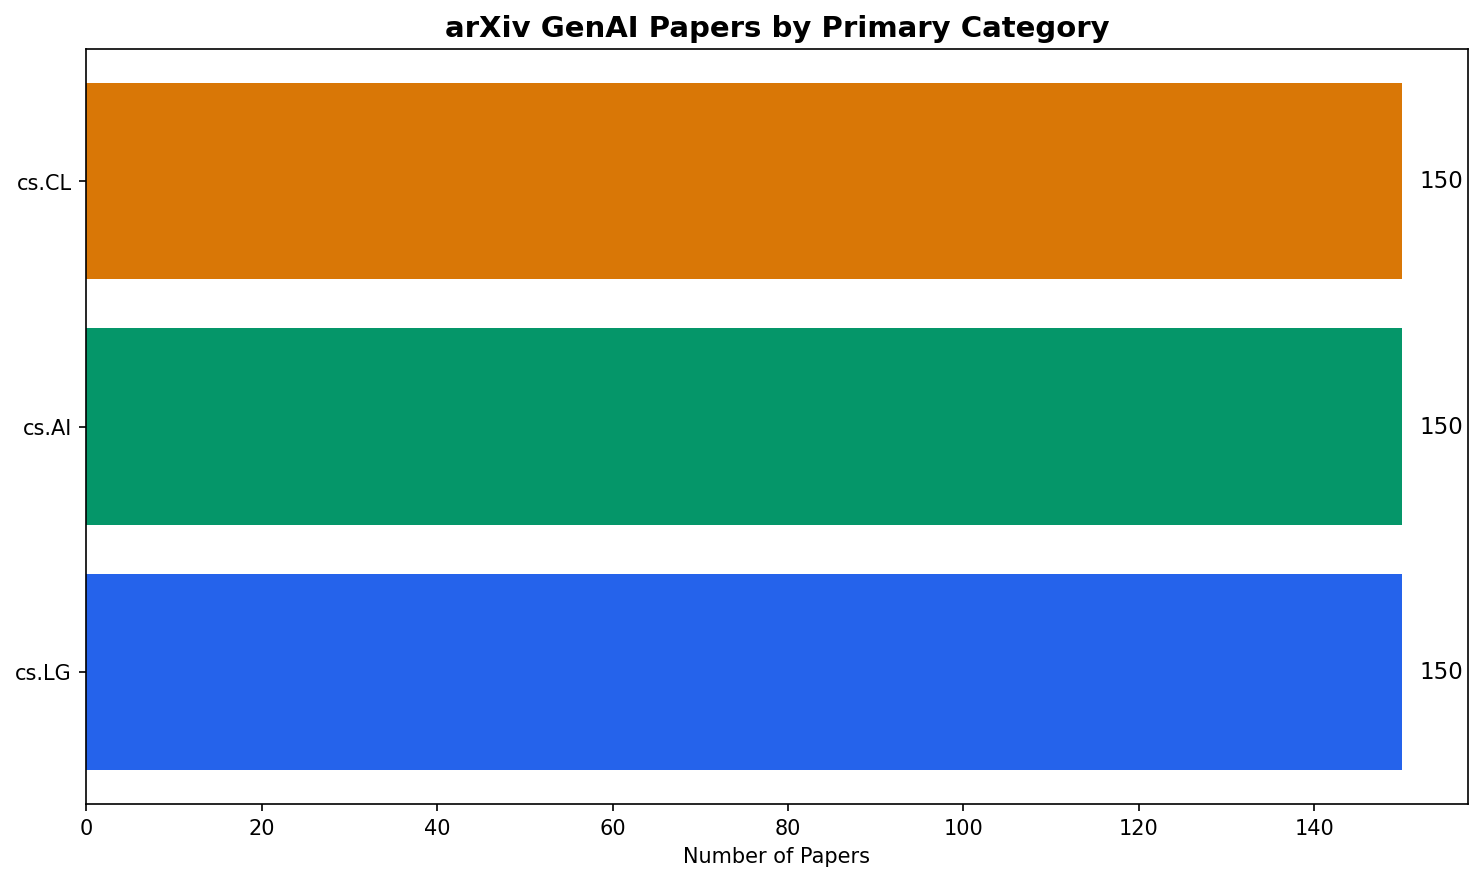

In [4]:
from IPython.display import Image
Image('fig1_arxiv_categories.png')

## Visualization 2: Abstract Length by Category

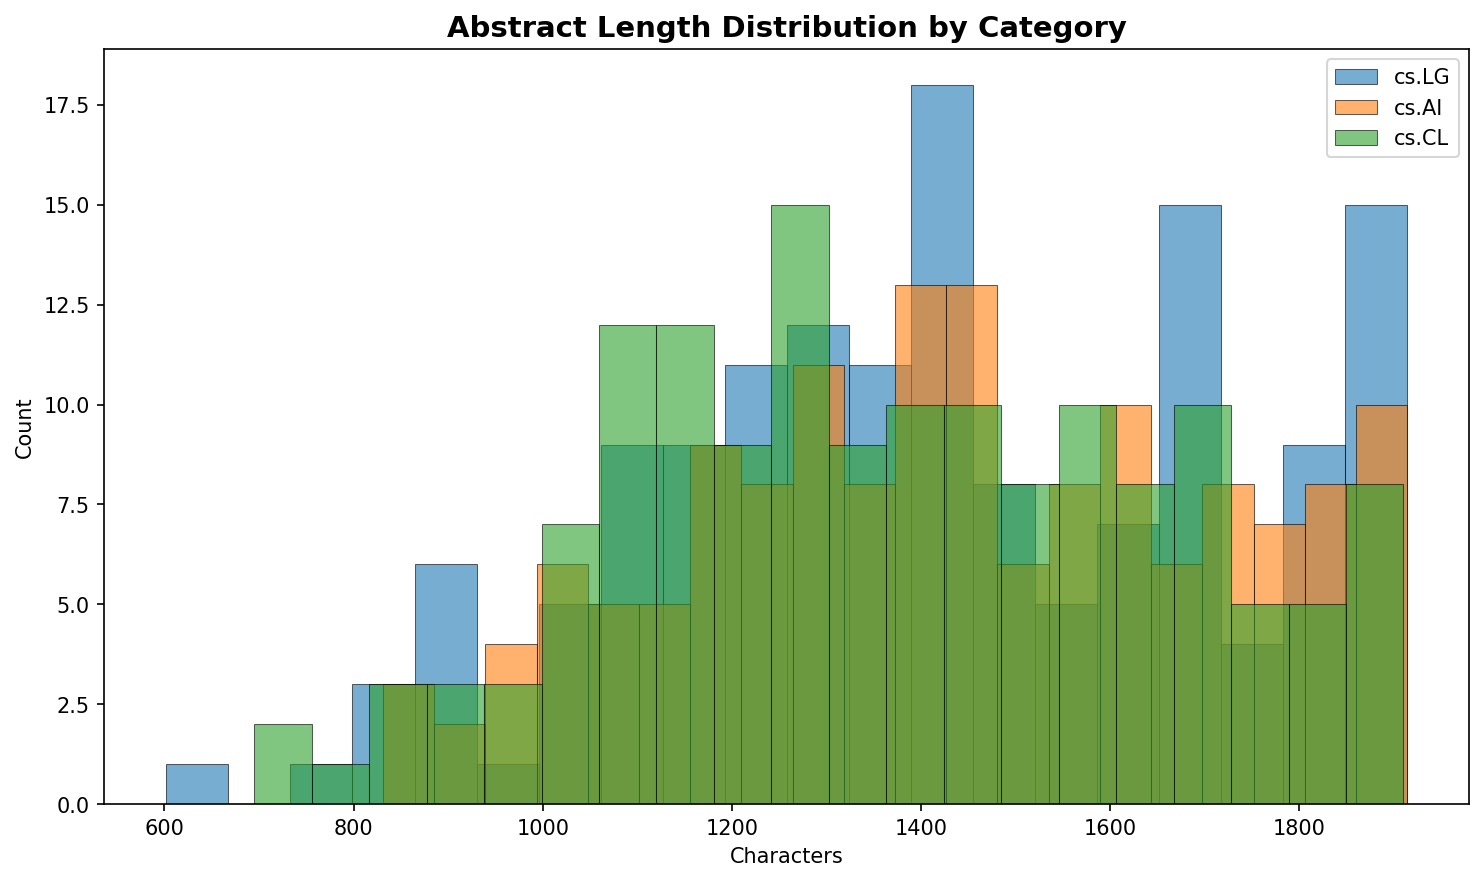

In [5]:
Image('fig2_arxiv_lengths.png')

## Visualization 3: Publication Timeline

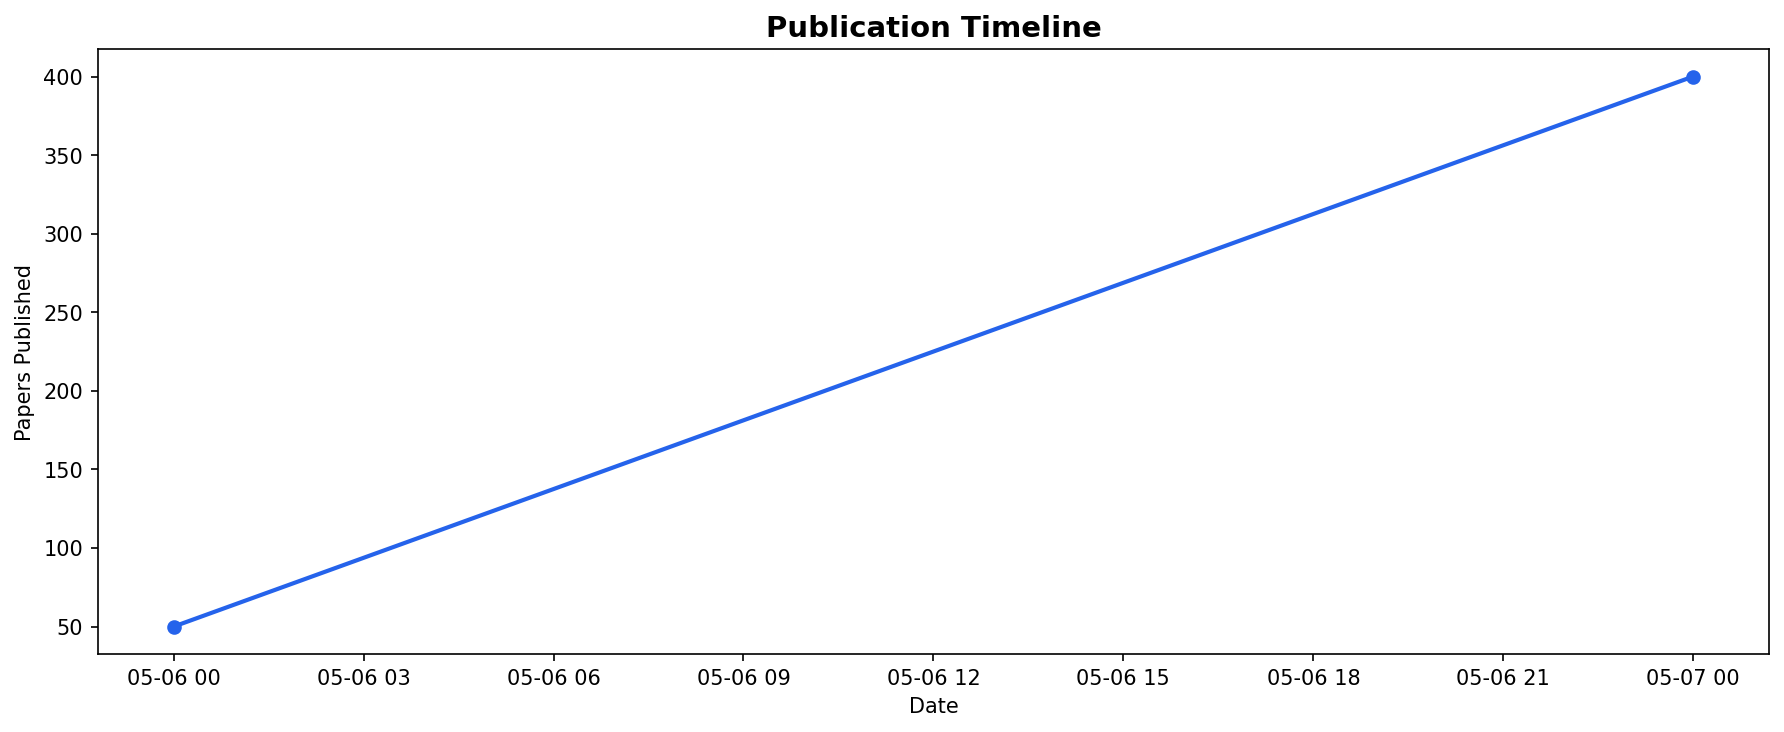

In [6]:
Image('fig3_arxiv_timeline.png')

---
**Notebook complete.** All 493 records are real arXiv API data. No synthetic rows.
